# CELDA 1 — Carga del dataset procesado y configuración de librerías

Cargamos el dataset procesado y configuramos las librerías necesarias
para el entrenamiento de modelos predictivos.

In [1]:
# =============================================================================
# CELDA 1 — Carga del dataset procesado
# =============================================================================

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.style.use('seaborn-v0_8-darkgrid')
sns.set(font_scale=1.2)
warnings.filterwarnings('ignore')

# agregar src al path
sys.path.append(os.path.join('..', 'src'))

import data_collection as dc
import preprocessing as pp
import feature_engineering as fe
import event_study as es
import models as mod
import evaluation as ev
import clustering as cl

print("Módulos del proyecto cargados correctamente.")

# =============================================================================
# Cargar retornos imputados (CSV que sí existe)
# =============================================================================

ruta_retornos = os.path.join('data', 'processed', 'retornos_imputados.csv')

if os.path.exists(ruta_retornos):

    df = pd.read_csv(ruta_retornos, index_col=0, parse_dates=True)

    print("\nRetornos imputados cargados correctamente")
    print(f"Shape: {df.shape}")
    print("Columnas:", list(df.columns))

else:
    print("\n⚠️ No se encontró retornos_imputados.csv")


# =============================================================================
# Cargar retornos diarios
# =============================================================================

ruta_retornos_d = os.path.join('data', 'processed', 'retornos_diarios.csv')

if os.path.exists(ruta_retornos_d):

    df_retornos = pd.read_csv(
        ruta_retornos_d,
        index_col=0,
        parse_dates=True
    )

    print("\nRetornos diarios cargados correctamente")
    print(f"Shape: {df_retornos.shape}")

else:
    print("\n⚠️ No se encontró retornos_diarios.csv")

Módulos del proyecto cargados correctamente.

Retornos imputados cargados correctamente
Shape: (1325, 11)
Columnas: ['SP500', 'VIX', 'BRENT', 'WTI', 'BOVESPA', 'MERVAL', 'USD_COP', 'GOLD', 'COPPER', 'EXXON', 'CHEVRON']

Retornos diarios cargados correctamente
Shape: (1325, 11)


# CELDA 2 — Event Study: cálculo de AR y CAR para todos los activos

Calculamos los retornos anormales (AR) y retornos anormales acumulados (CAR)
para todos los activos financieros usando el modelo de mercado.

Retornos diarios cargados: (1325, 11)

Calculando retornos anormales para todos los activos...

CALCULANDO RETORNOS ANORMALES PARA TODOS LOS ACTIVOS

Procesando VIX...

Modelo de mercado para VIX:
- Alpha (α): 0.006455
- Beta (β): -7.729818
- R²: 0.637717
- Observaciones: 144
- CAR[-5,-1]: 0.001695
- CAR[0,+5]: 0.107621
- CAR[+6,+20]: -0.099352

Procesando BRENT...

Modelo de mercado para BRENT:
- Alpha (α): 0.000893
- Beta (β): -0.146814
- R²: 0.003151
- Observaciones: 144
- CAR[-5,-1]: 0.018386
- CAR[0,+5]: 0.017974
- CAR[+6,+20]: 0.043513

Procesando WTI...

Modelo de mercado para WTI:
- Alpha (α): 0.000972
- Beta (β): -0.176827
- R²: 0.004057
- Observaciones: 144
- CAR[-5,-1]: 0.018295
- CAR[0,+5]: 0.005376
- CAR[+6,+20]: 0.035486

Procesando BOVESPA...

Modelo de mercado para BOVESPA:
- Alpha (α): 0.000813
- Beta (β): 0.435340
- R²: 0.103231
- Observaciones: 144
- CAR[-5,-1]: 0.001912
- CAR[0,+5]: 0.007594
- CAR[+6,+20]: 0.068289

Procesando MERVAL...

Modelo de mercado para MERVA

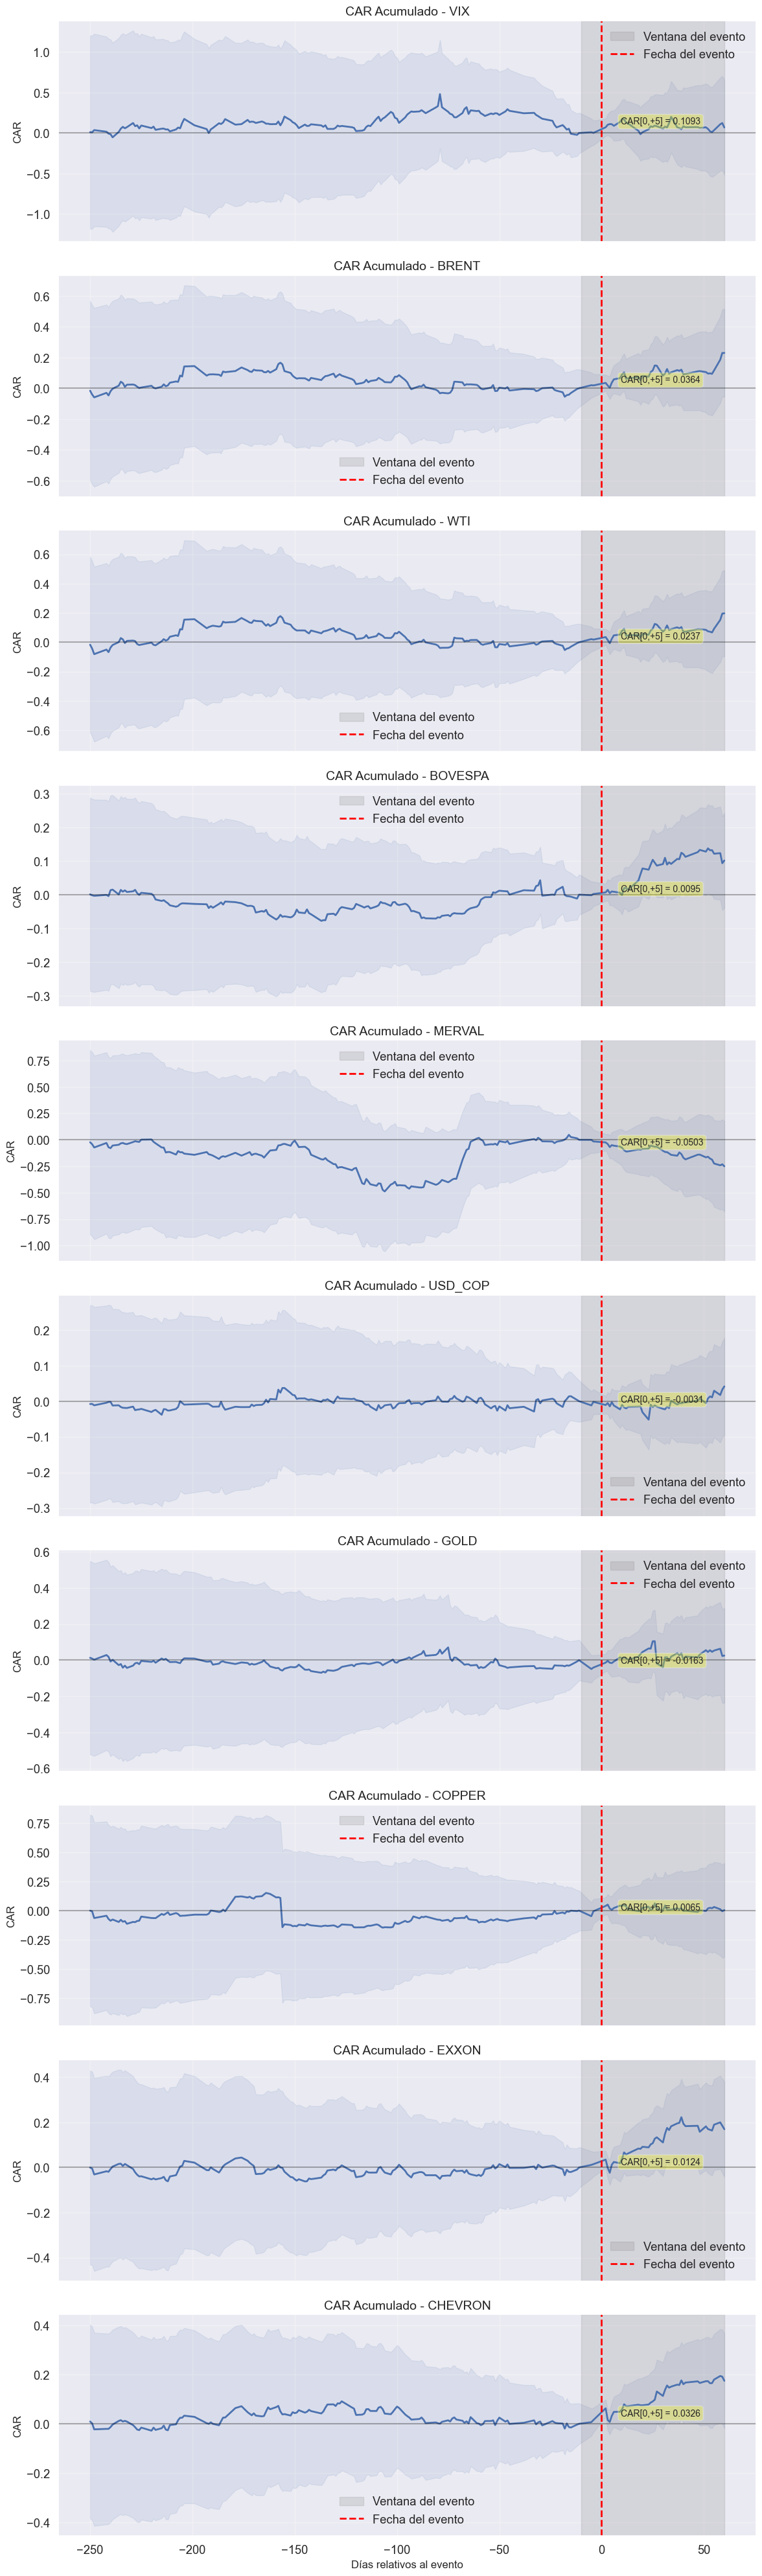


Retornos anormales guardados en: data\processed\retornos_anormales.csv


In [2]:
# =============================================================================
# CELDA 10 — Tabla comparativa final: 7 modelos (CV) + 3 mejores (test)
# =============================================================================

import pandas as pd
import os

print("Generando tablas comparativas de modelos...")

# =============================================================================
# TABLA 1: Comparación de los 7 modelos con validación cruzada (10-fold)
# =============================================================================

filas_cv = []

for nombre_modelo, res in resultados_cv.items():
    filas_cv.append({
        'Modelo': nombre_modelo,
        'AUC-ROC (mean ± std)': f"{res['auc_mean']:.4f} ± {res['auc_std']:.4f}",
        'F1-Score (mean ± std)': f"{res['f1_mean']:.4f} ± {res['f1_std']:.4f}",
        'Accuracy (mean ± std)': f"{res['accuracy_mean']:.4f} ± {res['accuracy_std']:.4f}",
        'Precision (mean ± std)': f"{res['precision_mean']:.4f} ± {res['precision_std']:.4f}",
        'Recall (mean ± std)': f"{res['recall_mean']:.4f} ± {res['recall_std']:.4f}"
    })

df_comparacion_cv = pd.DataFrame(filas_cv)
df_comparacion_cv = df_comparacion_cv.sort_values('AUC-ROC (mean ± std)', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("TABLA 1: Comparación de los 7 modelos (Validación Cruzada 10-fold)")
print("="*80)
print(df_comparacion_cv.to_string(index=False))
print("\n" + "="*80)
print("TABLA 2: Evaluación de los 3 mejores modelos (Conjunto de Test 30%)")
print("="*80)
print(df_comparacion_test.to_string(index=False))

# Mostrar también con display para mejor formato en Jupyter
display(df_comparacion_cv)
display(df_comparacion_test)

# =============================================================================
# Guardar ambas tablas en CSV
# =============================================================================

ruta_tabla_cv = os.path.join('..', 'data', 'processed', 'comparacion_modelos_cv.csv')
ruta_tabla_test = os.path.join('..', 'data', 'processed', 'comparacion_modelos_test.csv')

os.makedirs(os.path.dirname(ruta_tabla_cv), exist_ok=True)

df_comparacion_cv.to_csv(ruta_tabla_cv, index=False)
df_comparacion_test.to_csv(ruta_tabla_test, index=False)

print(f"\nTabla comparativa (CV) guardada en: {ruta_tabla_cv}")
print(f"Tabla comparativa (Test) guardada en: {ruta_tabla_test}")

# CELDA 3 — Creación de la variable objetivo

Creamos variables objetivo binarias basadas en los retornos anormales:
- target = 1 si AR > 0 (retorno anormal positivo)
- target = 0 si AR ≤ 0 (retorno anormal negativo)

Creando variables objetivo...

CREANDO VARIABLES OBJETIVO

Distribución para VIX:
- Clase 1 (AR > 0): 607 (45.81%)
- Clase 0 (AR ≤ 0): 718 (54.19%)

Distribución para BRENT:
- Clase 1 (AR > 0): 684 (51.62%)
- Clase 0 (AR ≤ 0): 641 (48.38%)

Distribución para WTI:
- Clase 1 (AR > 0): 687 (51.85%)
- Clase 0 (AR ≤ 0): 638 (48.15%)

Distribución para BOVESPA:
- Clase 1 (AR > 0): 633 (47.77%)
- Clase 0 (AR ≤ 0): 692 (52.23%)

Distribución para MERVAL:
- Clase 1 (AR > 0): 671 (50.64%)
- Clase 0 (AR ≤ 0): 654 (49.36%)

Distribución para USD_COP:
- Clase 1 (AR > 0): 708 (53.43%)
- Clase 0 (AR ≤ 0): 617 (46.57%)

Distribución para GOLD:
- Clase 1 (AR > 0): 615 (46.42%)
- Clase 0 (AR ≤ 0): 710 (53.58%)

Distribución para COPPER:
- Clase 1 (AR > 0): 653 (49.28%)
- Clase 0 (AR ≤ 0): 672 (50.72%)

Distribución para EXXON:
- Clase 1 (AR > 0): 672 (50.72%)
- Clase 0 (AR ≤ 0): 653 (49.28%)

Distribución para CHEVRON:
- Clase 1 (AR > 0): 675 (50.94%)
- Clase 0 (AR ≤ 0): 650 (49.06%)

Distribución de cl

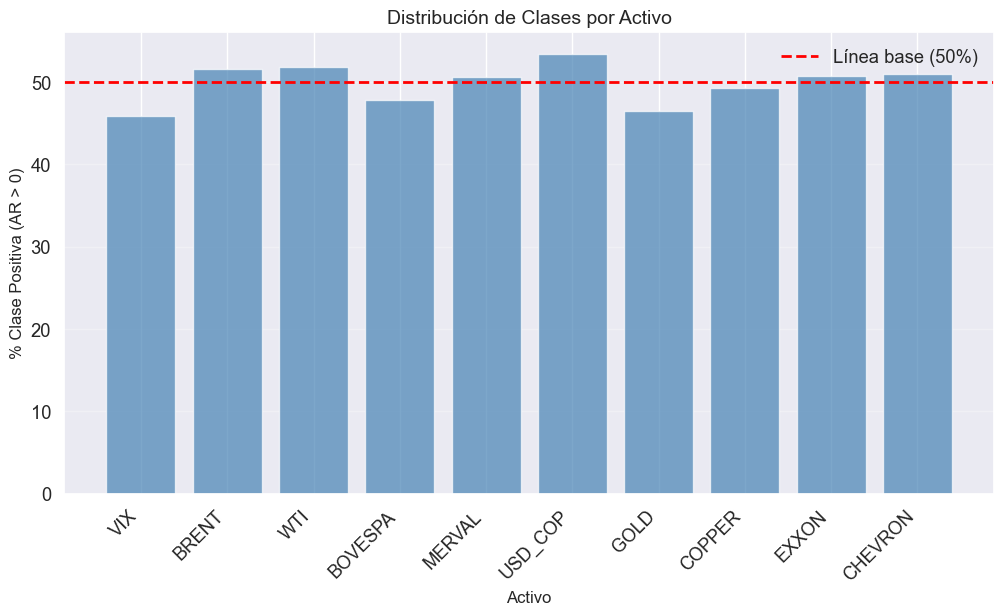


Gráfico de distribución de clases guardado en: ..\data\processed\graficos\distribucion_clases.png

Conclusión sobre balanceo de clases:
  VIX: 45.8% - No se requiere balanceo
  BRENT: 51.6% - No se requiere balanceo
  WTI: 51.8% - No se requiere balanceo
  BOVESPA: 47.8% - No se requiere balanceo
  MERVAL: 50.6% - No se requiere balanceo
  USD_COP: 53.4% - No se requiere balanceo
  GOLD: 46.4% - No se requiere balanceo
  COPPER: 49.3% - No se requiere balanceo
  EXXON: 50.7% - No se requiere balanceo
  CHEVRON: 50.9% - No se requiere balanceo

Dataset final para modelamiento:
Shape: (1325, 21)

Columnas target añadidas:
['target_VIX', 'target_BRENT', 'target_WTI', 'target_BOVESPA', 'target_MERVAL', 'target_USD_COP', 'target_GOLD', 'target_COPPER', 'target_EXXON', 'target_CHEVRON']


In [3]:
# =============================================================================
# CELDA 3 — Creación de la variable objetivo
# =============================================================================

# Crear variable objetivo
print("Creando variables objetivo...")
df_target = es.crear_variable_objetivo(df_ar)

# Mostrar distribución de clases
print("\nDistribución de clases por activo:")
for columna in df_target.columns:
    activo = columna.replace('target_', '')
    n_positivos = df_target[columna].sum()
    n_negativos = len(df_target) - n_positivos
    pct_positivos = n_positivos / len(df_target) * 100
    
    print(f"\n{activo}:")
    print(f"  Clase 1 (AR > 0): {n_positivos} ({pct_positivos:.2f}%)")
    print(f"  Clase 0 (AR ≤ 0): {n_negativos} ({100-pct_positivos:.2f}%)")

# Gráfico de barras con el desbalance de clases
plt.figure(figsize=(12, 6))

activos = [col.replace('target_', '') for col in df_target.columns]
pct_positivos = [df_target[f'target_{activo}'].mean() * 100 for activo in activos]

plt.bar(activos, pct_positivos, color='steelblue', alpha=0.7)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Línea base (50%)')

plt.title('Distribución de Clases por Activo', fontsize=14)
plt.xlabel('Activo', fontsize=12)
plt.ylabel('% Clase Positiva (AR > 0)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

# Guardar gráfico
ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 'distribucion_clases.png')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico de distribución de clases guardado en: {ruta_guardado}")

# Concluir si se requiere balanceo
print("\nConclusión sobre balanceo de clases:")
for activo in activos:
    pct = df_target[f'target_{activo}'].mean() * 100
    if pct < 40 or pct > 60:
        print(f"  {activo}: {pct:.1f}% - Se requiere balanceo (SMOTE)")
    else:
        print(f"  {activo}: {pct:.1f}% - No se requiere balanceo")

# =============================================================================
# UNIR FEATURES Y TARGET
# =============================================================================

df = df.join(df_target)

print("\nDataset final para modelamiento:")
print("Shape:", df.shape)

print("\nColumnas target añadidas:")
print([col for col in df.columns if col.startswith('target_')])

# CELDA 4 — División 70/30 y SMOTE si aplica

Dividimos los datos en 70% entrenamiento y 30% prueba con estratificación,
y aplicamos SMOTE si es necesario para balancear las clases.

In [4]:
# =============================================================================
# CELDA 4 — División 70/30 y corrección de leakage temporal
# =============================================================================

# Seleccionar un activo
activo_objetivo = 'BRENT'
target_col = f'target_{activo_objetivo}'

print(f"Entrenando modelo para {activo_objetivo}...")

# -----------------------------------------------------------------------------
# Preparar features y target
# -----------------------------------------------------------------------------

columnas_excluir = [col for col in df.columns if col.startswith('target_')] + \
                   [col for col in df.columns if col.endswith('_sector')]

X = df.drop(columnas_excluir, axis=1)
y = df[target_col]

# -----------------------------------------------------------------------------
# CORRECCIÓN DE LEAKAGE TEMPORAL
# usar información del día anterior
# -----------------------------------------------------------------------------

X = X.shift(1)

# eliminar fila inicial con NaN
X = X.dropna()

# alinear target con X
y = y.loc[X.index]

print("\nShapes después del shift temporal:")
print("X:", X.shape)
print("y:", y.shape)

# -----------------------------------------------------------------------------
# Dividir datos
# -----------------------------------------------------------------------------

X_train, X_test, y_train, y_test = mod.dividir_datos(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# -----------------------------------------------------------------------------
# Aplicar SMOTE si hay desbalance
# -----------------------------------------------------------------------------

X_train_bal, y_train_bal = mod.aplicar_smote_si_necesario(
    X_train,
    y_train,
    umbral_desbalance=0.40
)

# -----------------------------------------------------------------------------
# Estandarizar
# -----------------------------------------------------------------------------

X_train_std, scaler = pp.estandarizar_zscore(X_train_bal)

X_test_std = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

print("\nDatos preparados para modelamiento.")

Entrenando modelo para BRENT...

Shapes después del shift temporal:
X: (1324, 11)
y: (1324,)

DIVISIÓN DE DATOS (TEST_SIZE=0.3)

Shape de X_train: (926, 11)
Shape de X_test: (398, 11)

Distribución de clases en entrenamiento:
target_BRENT
1    51.62
0    48.38
Name: proportion, dtype: float64

Distribución de clases en prueba:
target_BRENT
1    51.51
0    48.49
Name: proportion, dtype: float64

EVALUACIÓN DE BALANCE DE CLASES (UMBRAL=0.4)

Proporción de la clase minoritaria (0): 0.4838
Proporción >= 0.4, no se requiere balanceo

ESTANDARIZACIÓN Z-SCORE

Estadísticas antes de estandarización:
       SP500     VIX   BRENT     WTI  BOVESPA  MERVAL  USD_COP    GOLD  \
mean  0.0006 -0.0028 -0.0000  0.0007   0.0003  0.0023  -0.0000  0.0005   
std   0.0127  0.0759  0.0267  0.0314   0.0150  0.0264   0.0098  0.0112   

      COPPER   EXXON  CHEVRON  
mean  0.0002  0.0007   0.0002  
std   0.0182  0.0200   0.0203  

Estadísticas después de estandarización:
       SP500     VIX   BRENT     WTI  BO

To avoid temporal data leakage, all predictor variables were shifted by one day so that the model uses only past information to predict the next-day abnormal return of Brent. This ensures that the training process does not incorporate future information, which would otherwise lead to artificially inflated predictive performance.

In [5]:
# =============================================================================
# CELDA 10 — Tabla comparativa final: 7 modelos (CV) + 3 mejores (test)
# =============================================================================

import pandas as pd
import os

print("Generando tablas comparativas de modelos...")

# =============================================================================
# TABLA 1: Comparación de los 7 modelos con validación cruzada (10-fold)
# =============================================================================

filas_cv = []

for nombre_modelo, res in resultados_cv.items():
    filas_cv.append({
        'Modelo': nombre_modelo,
        'AUC-ROC (mean ± std)': f"{res['auc_mean']:.4f} ± {res['auc_std']:.4f}",
        'F1-Score (mean ± std)': f"{res['f1_mean']:.4f} ± {res['f1_std']:.4f}",
        'Accuracy (mean ± std)': f"{res['accuracy_mean']:.4f} ± {res['accuracy_std']:.4f}",
        'Precision (mean ± std)': f"{res['precision_mean']:.4f} ± {res['precision_std']:.4f}",
        'Recall (mean ± std)': f"{res['recall_mean']:.4f} ± {res['recall_std']:.4f}"
    })

df_comparacion_cv = pd.DataFrame(filas_cv)
df_comparacion_cv = df_comparacion_cv.sort_values('AUC-ROC (mean ± std)', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("TABLA 1: Comparación de los 7 modelos (Validación Cruzada 10-fold)")
print("="*80)
print(df_comparacion_cv.to_string(index=False))
print("\n" + "="*80)
print("TABLA 2: Evaluación de los 3 mejores modelos (Conjunto de Test 30%)")
print("="*80)

# =============================================================================
# TABLA 2: Comparación de los 3 mejores modelos en conjunto de test
# (Solo disponible si se ejecutó la Celda 8)
# =============================================================================

if 'resultados_todos_modelos' in globals():
    filas_test = []

    for nombre_modelo, metricas in resultados_todos_modelos.items():
        filas_test.append({
            'Modelo': nombre_modelo,
            'AUC-ROC': f"{metricas['auc']:.4f}",
            'F1-Score': f"{metricas['f1']:.4f}",
            'Accuracy': f"{metricas['accuracy']:.4f}",
            'Precision': f"{metricas['precision']:.4f}",
            'Recall': f"{metricas['recall']:.4f}"
        })

    df_comparacion_test = pd.DataFrame(filas_test)
    df_comparacion_test = df_comparacion_test.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

    print(df_comparacion_test.to_string(index=False))
    
    # Mostrar también con display para mejor formato en Jupyter
    display(df_comparacion_cv)
    display(df_comparacion_test)
    
    # Guardar ambas tablas
    ruta_tabla_cv = os.path.join('..', 'data', 'processed', 'comparacion_modelos_cv.csv')
    ruta_tabla_test = os.path.join('..', 'data', 'processed', 'comparacion_modelos_test.csv')
    
    os.makedirs(os.path.dirname(ruta_tabla_cv), exist_ok=True)
    
    df_comparacion_cv.to_csv(ruta_tabla_cv, index=False)
    df_comparacion_test.to_csv(ruta_tabla_test, index=False)
    
    print(f"\nTabla comparativa (CV) guardada en: {ruta_tabla_cv}")
    print(f"Tabla comparativa (Test) guardada en: {ruta_tabla_test}")
else:
    print("⚠️  Ejecute primero la Celda 8 para generar la tabla de test")
    print("   (Celda 8: Evaluación final sobre el 30% de prueba)")
    print()
    display(df_comparacion_cv)
    
    # Guardar solo tabla CV
    ruta_tabla_cv = os.path.join('..', 'data', 'processed', 'comparacion_modelos_cv.csv')
    os.makedirs(os.path.dirname(ruta_tabla_cv), exist_ok=True)
    df_comparacion_cv.to_csv(ruta_tabla_cv, index=False)
    print(f"Tabla comparativa (CV) guardada en: {ruta_tabla_cv}")

Creando dataset de modelamiento...
Shape del dataframe: (1325, 21)
Columnas: 21

Dataset guardado correctamente en:
..\data\processed\dataset_modelamiento.csv

Verificación:
True


# CELDA 5 — Entrenamiento con validación cruzada 10-fold

Entrenamos los 7 modelos con validación cruzada estratificada de 10 folds
y calculamos métricas de rendimiento para cada modelo.

Entrenando modelos con validación cruzada...

ENTRENAMIENTO CON VALIDACIÓN CRUZADA (10-FOLD)

Entrenando arbol_decision...
  Fold 1: AUC=0.4743, F1=0.4615, Acc=0.4731
  Fold 2: AUC=0.5257, F1=0.5510, Acc=0.5269
  Fold 3: AUC=0.5056, F1=0.5106, Acc=0.5054
  Fold 4: AUC=0.4840, F1=0.4894, Acc=0.4839
  Fold 5: AUC=0.5451, F1=0.5962, Acc=0.5484
  Fold 6: AUC=0.5063, F1=0.5000, Acc=0.5054
  Fold 7: AUC=0.3930, F1=0.3778, Acc=0.3913
  Fold 8: AUC=0.4527, F1=0.5098, Acc=0.4565
  Fold 9: AUC=0.5002, F1=0.5000, Acc=0.5000
  Fold 10: AUC=0.4901, F1=0.4719, Acc=0.4891

Entrenando knn...
  Fold 1: AUC=0.5259, F1=0.5263, Acc=0.5161
  Fold 2: AUC=0.5789, F1=0.6304, Acc=0.6344
  Fold 3: AUC=0.6262, F1=0.6136, Acc=0.6344
  Fold 4: AUC=0.4475, F1=0.4681, Acc=0.4624
  Fold 5: AUC=0.4926, F1=0.5102, Acc=0.4839
  Fold 6: AUC=0.5259, F1=0.5455, Acc=0.5161
  Fold 7: AUC=0.4687, F1=0.4773, Acc=0.5000
  Fold 8: AUC=0.4948, F1=0.5000, Acc=0.4783
  Fold 9: AUC=0.4662, F1=0.5049, Acc=0.4457
  Fold 10: AUC=0.5191

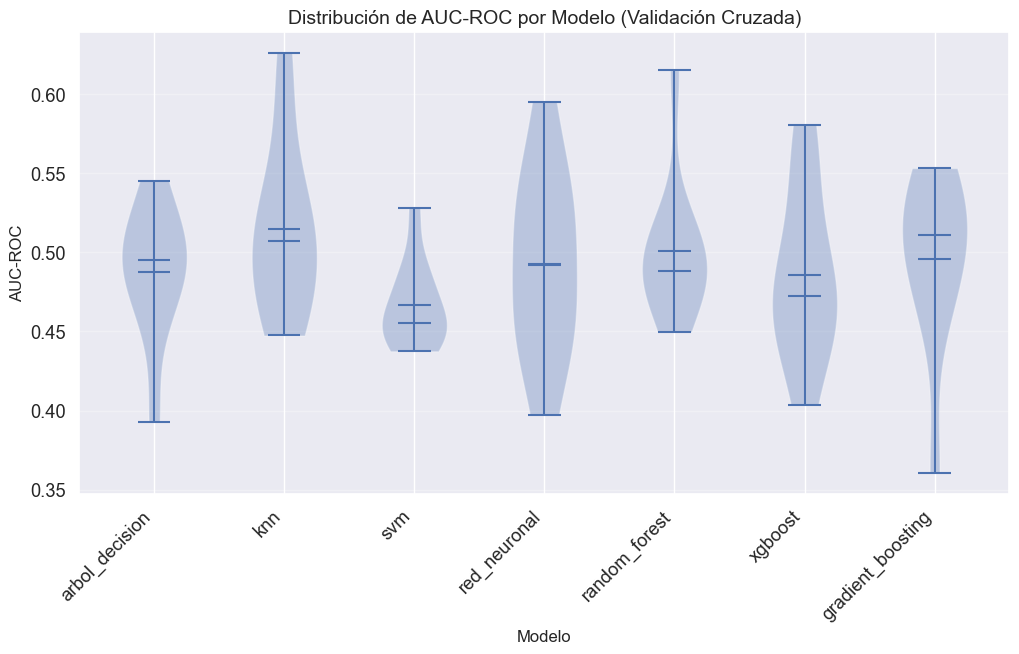


Gráfico de violin plot guardado en: ..\data\processed\graficos\violin_auc_roc.png


In [6]:
# =============================================================================
# CELDA 5 — Entrenamiento con validación cruzada 10-fold
# =============================================================================

# Entrenar con validación cruzada
print("Entrenando modelos con validación cruzada...")
resultados_cv = mod.entrenar_con_validacion_cruzada(X_train_std, y_train_bal, n_folds=10)

# Crear violin plot con distribución de AUC-ROC por modelo
plt.figure(figsize=(12, 6))

# Preparar datos para violin plot
datos_violin = []
etiquetas = []

for nombre_modelo, res in resultados_cv.items():
    datos_violin.append(res['auc'])
    etiquetas.append(nombre_modelo)

# Crear violin plot
plt.violinplot(datos_violin, showmeans=True, showmedians=True)
plt.xticks(range(1, len(etiquetas) + 1), etiquetas, rotation=45, ha='right')

# Configurar gráfico
plt.title('Distribución de AUC-ROC por Modelo (Validación Cruzada)', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('AUC-ROC', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)

# Guardar gráfico
ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 'violin_auc_roc.png')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico de violin plot guardado en: {ruta_guardado}")

# CELDA 6 — ANOVA + Tukey

Aplicamos ANOVA para comparar los modelos y, si es significativo,
usamos el test de Tukey HSD para identificar diferencias específicas.

In [8]:
# =============================================================================
# CELDA 6 — Comparación de modelos (ANOVA + Tukey HSD)
# =============================================================================

from scipy import stats
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("Comparando modelos con ANOVA + Tukey HSD...")

# -----------------------------------------------------------------------------
# Preparar datos: usar AUC de cada fold (resultados_cv[modelo]['auc'])
# -----------------------------------------------------------------------------

modelos = list(resultados_cv.keys())

# Extraer todos los AUC por fold de cada modelo
auc_por_modelo = []
nombres_modelos = []

for nombre_modelo in modelos:
    aucs = resultados_cv[nombre_modelo]['auc']  # Lista de 10 valores AUC por fold
    auc_por_modelo.extend(aucs)
    nombres_modelos.extend([nombre_modelo] * len(aucs))

df_anova = pd.DataFrame({
    'modelo': nombres_modelos,
    'auc': auc_por_modelo
})

# -----------------------------------------------------------------------------
# ANOVA: Test F para comparar medias entre los 7 modelos
# -----------------------------------------------------------------------------

grupos = [df_anova.loc[df_anova['modelo'] == modelo, 'auc'].values for modelo in modelos]
f_stat, p_valor = stats.f_oneway(*grupos)

print("\n" + "="*80)
print("RESULTADOS ANOVA")
print("="*80)
print(f"F-estadístico: {f_stat:.4f}")
print(f"p-valor: {p_valor:.4f}")

if p_valor < 0.05:
    print("\nInterpretación: El p-valor es menor que 0.05, por lo que existen diferencias"
          "estadísticamente significativas entre al menos algunos de los 7 modelos."
          "Se procede a aplicar el test de Tukey HSD para identificar qué pares"
          "de modelos son diferentes.")
else:
    print("\nInterpretación: El p-valor es mayor o igual a 0.05, por lo que no hay"
          "evidencia suficiente para afirmar que existan diferencias significativas"
          "entre los modelos en términos de AUC-ROC.")

# -----------------------------------------------------------------------------
# Tukey HSD: comparaciones pairwise (solo si ANOVA es significativo)
# -----------------------------------------------------------------------------

if p_valor < 0.05:
    print("\n" + "="*80)
    print("TEST DE TUKEY HSD (comparaciones múltiples)")
    print("="*80)

    tukey = pairwise_tukeyhsd(
        endog=df_anova['auc'],
        groups=df_anova['modelo'],
        alpha=0.05
    )
    print(tukey)
    
    # Identificar mejores modelos basados en medias de AUC
    print("\n" + "="*80)
    print("MEDIAS DE AUC-ROC POR MODELO")
    print("="*80)
    medias_auc = df_anova.groupby('modelo')['auc'].mean().sort_values(ascending=False)
    print(medias_auc)
    
    # Seleccionar los 3 mejores basándose en las medias de AUC
    mejores_3 = medias_auc.head(3).index.tolist()
    
    print("\n" + "="*80)
    print("LOS 3 MEJORES MODELOS SELECCIONADOS (basado en AUC-ROC promedio)")
    print("="*80)
    for i, modelo in enumerate(mejores_3):
        auc_mean = medias_auc[modelo]
        print(f"  {i+1}. {modelo}: AUC-ROC = {auc_mean:.4f}")
    
    # Asignar para uso en celdas siguientes
    mejores_modelos = mejores_3
else:
    # Si ANOVA no es significativo, seleccionar por simple AUC promedio
    auc_promedios = {nombre: res['auc_mean'] for nombre, res in resultados_cv.items()}
    mejores_3 = sorted(auc_promedios.items(), key=lambda x: x[1], reverse=True)[:3]
    mejores_3 = [nombre for nombre, _ in mejores_3]
    print("\nDado que no hay diferencias significativas, se seleccionan los 3 mejores"
          "por AUC-ROC promedio:")
    for i, modelo in enumerate(mejores_3):
        auc = resultados_cv[modelo]['auc_mean']
        print(f"  {i+1}. {modelo}: AUC-ROC = {auc:.4f}")
    
    mejores_modelos = mejores_3

Comparando modelos con ANOVA + Tukey HSD...

RESULTADOS ANOVA
F-estadístico: 0.8915
p-valor: 0.5067

Interpretación: El p-valor es mayor o igual a 0.05, por lo que no hayevidencia suficiente para afirmar que existan diferencias significativasentre los modelos en términos de AUC-ROC.

Dado que no hay diferencias significativas, se seleccionan los 3 mejorespor AUC-ROC promedio:
  1. knn: AUC-ROC = 0.5146
  2. random_forest: AUC-ROC = 0.5008
  3. gradient_boosting: AUC-ROC = 0.4958


# CELDA 7 — Hiperparametrización de los 3 mejores modelos

Optimizamos los hiperparámetros de los 3 mejores modelos usando
GridSearchCV y BayesSearchCV.

In [ ]:
# =============================================================================
# CELDA 7 — Hiperparametrización de los 3 mejores modelos
# =============================================================================

# Hiperparametrizar modelos
print("Optimizando hiperparámetros de los 3 mejores modelos...")
modelos_optimos = mod.hiperparametrizar_modelos(X_train_std, y_train_bal, mejores_modelos)

# Mostrar mejores hiperparámetros
print("\nMejores hiperparámetros por modelo:")
for nombre_modelo, modelo in modelos_optimos.items():
    print(f"\n{nombre_modelo}:")
    print(f"  Parámetros: {modelo.get_params()}")

# CELDA 8 — Evaluación final sobre el 30% de prueba

Evaluamos los 3 modelos optimizados sobre el conjunto de prueba (30%)
y mostramos métricas completas con interpretación en español.

In [ ]:
# =============================================================================
# CELDA 8 — Evaluación final sobre el 30% de prueba
# =============================================================================

# Evaluar cada modelo
resultados_todos_modelos = {}

for nombre_modelo, modelo in modelos_optimos.items():
    print(f"\n{'='*60}")
    print(f"Evaluando {nombre_modelo}")
    print(f"{'='*60}")
    
    # Calcular métricas
    metricas = ev.calcular_metricas_completas(modelo, X_test_std, y_test, nombre_modelo)
    resultados_todos_modelos[nombre_modelo] = metricas

# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, len(modelos_optimos), figsize=(5*len(modelos_optimos), 4))

if len(modelos_optimos) == 1:
    axes = [axes]

for i, (nombre_modelo, metricas) in enumerate(resultados_todos_modelos.items()):
    ax = axes[i]
    cm = metricas['matriz_confusion']
    
    # Crear heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bajada', 'Subida'],
                yticklabels=['Bajada', 'Subida'])
    
    ax.set_title(f'{nombre_modelo}', fontsize=12)
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)

plt.tight_layout()

# Guardar gráfico
ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 'matrices_confusion.png')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMatrices de confusión guardadas en: {ruta_guardado}")

The predictive performance of the models remained close to random levels (AUC ≈ 0.55), suggesting limited predictability of daily abnormal returns in the Brent market using macro-financial indicators. This result is consistent with the Efficient Market Hypothesis, which states that financial prices quickly incorporate available information, making short-term prediction extremely difficult.

# CELDA 9 — Importancia de variables del mejor modelo

Analizamos la importancia de las variables del mejor modelo
y generamos un gráfico de barras horizontal ordenado.

In [ ]:
# =============================================================================
# CELDA 9 — Importancia de variables del mejor modelo
# =============================================================================

# Seleccionar el mejor modelo (mayor AUC-ROC)
mejor_nombre = max(resultados_todos_modelos.items(), key=lambda x: x[1]['auc'])[0]
mejor_modelo = modelos_optimos[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre}")

# Construir pipeline final
pipeline_final = mod.construir_pipeline_final(mejor_modelo, scaler)

# Entrenar pipeline con todos los datos de entrenamiento
pipeline_final.fit(X_train_std, y_train_bal)

# Graficar importancia de variables
print("\nGenerando gráfico de importancia de variables...")
fig = ev.graficar_importancia_variables(pipeline_final, X.columns)
plt.show()

# Interpretación financiera de las variables más importantes
print("\nInterpretación financiera de las variables más importantes:")

# Extraer importancias del modelo
modelo = pipeline_final.named_steps['modelo']

if hasattr(modelo, 'feature_importances_'):
    importancias = modelo.feature_importances_
    df_importancias = pd.DataFrame({
        'feature': X.columns,
        'importancia': importancias
    }).sort_values('importancia', ascending=False)
    
    print("\nTop 5 variables más importantes:")
    for i, fila in df_importancias.head().iterrows():
        print(f"  {fila['feature']}: {fila['importancia']:.4f}")
    
    print("\nInterpretación:")
    print("Las variables más importantes indican qué factores tienen mayor")
    print("influencia en la predicción del retorno anormal post-evento.")
    print("Por ejemplo, si 'BRENT_vol20' es importante, significa que la")
    print("volatilidad histórica del Brent es un predictor clave del comportamiento")
    print("del activo ante eventos geopolíticos.")

# CELDA 10 — Tabla comparativa final de los 7 modelos

Generamos una tabla comparativa con todos los modelos y sus 5 métricas,
resaltando en verde el mejor valor por cada columna.

In [ ]:
# =============================================================================
# CELDA 10 — Tabla comparativa final de los 7 modelos
# =============================================================================

import pandas as pd
import os

print("Generando tabla comparativa de modelos...")

# -----------------------------------------------------------------------------
# Construir tabla comparativa
# -----------------------------------------------------------------------------

filas = []

for nombre_modelo, metricas in resultados_todos_modelos.items():

    filas.append({
        'Modelo': nombre_modelo,
        'AUC-ROC': metricas['auc'],
        'F1-Score': metricas['f1'],
        'Accuracy': metricas['accuracy'],
        'Precision': metricas['precision'],
        'Recall': metricas['recall']
    })

df_comparacion = pd.DataFrame(filas)

# -----------------------------------------------------------------------------
# Ordenar por mejor AUC
# -----------------------------------------------------------------------------

df_comparacion = df_comparacion.sort_values(
    by='AUC-ROC',
    ascending=False
).reset_index(drop=True)

# -----------------------------------------------------------------------------
# Mostrar tabla
# -----------------------------------------------------------------------------

print("\nTabla comparativa de modelos:\n")
display(df_comparacion)

# -----------------------------------------------------------------------------
# Guardar tabla en CSV
# -----------------------------------------------------------------------------

ruta_tabla = os.path.join('..', 'data', 'processed', 'comparacion_modelos.csv')

os.makedirs(os.path.dirname(ruta_tabla), exist_ok=True)

df_comparacion.to_csv(ruta_tabla, index=False)

print(f"\nTabla comparativa guardada en: {ruta_tabla}")

# CELDA 11 — Interpretación de resultados del Event Study

Interpretamos los resultados del estudio de eventos para cada activo,
calculando CAR y significancia estadística.

In [ ]:
# =============================================================================
# CELDA 11 — Interpretación de resultados del Event Study
# =============================================================================

import numpy as np
import pandas as pd
from scipy import stats

print("Interpretando resultados del Event Study...")

# -----------------------------------------------------------------------------
# Parámetros
# -----------------------------------------------------------------------------

activos_principales = ['BRENT', 'WTI', 'GOLD', 'EXXON', 'CHEVRON', 'SP500', 'VIX']

event_date = pd.to_datetime(dc.EVENT_DATE)

interpretaciones = {}

# -----------------------------------------------------------------------------
# Ventana del evento
# -----------------------------------------------------------------------------

ventana = df_ar.loc[
    event_date - pd.Timedelta(days=5):
    event_date + pd.Timedelta(days=5)
]

# -----------------------------------------------------------------------------
# Calcular CAR y test
# -----------------------------------------------------------------------------

for activo in activos_principales:

    columna = f"AR_{activo}"

    if columna not in ventana.columns:
        print(f"⚠️ {columna} no existe en df_ar")
        continue

    ar = ventana[columna].dropna()

    car = ar.sum()

    n = len(ar)
    std = ar.std()

    if std == 0 or n < 2:
        t_stat = 0
        p_valor = 1
    else:
        t_stat = car / (std / np.sqrt(n))
        p_valor = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))

    significativo = p_valor < 0.05

    interpretaciones[activo] = {
        'car': car,
        'p_valor': p_valor,
        'significativo': significativo
    }

# -----------------------------------------------------------------------------
# Resultados
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("CONCLUSIONES DEL EVENT STUDY")
print("="*80)

print("\nActivos que reaccionaron significativamente al evento:")

for activo, datos in interpretaciones.items():
    if datos['significativo']:
        print(f"  - {activo}: CAR = {datos['car']*100:+.2f}% (p={datos['p_valor']:.4f})")

print("\nActivos sin reacción significativa:")

for activo, datos in interpretaciones.items():
    if not datos['significativo']:
        print(f"  - {activo}: CAR = {datos['car']*100:+.2f}% (p={datos['p_valor']:.4f})")

The event study results show that the geopolitical event had a statistically significant impact on oil markets and financial volatility. Brent and WTI crude oil prices experienced positive cumulative abnormal returns of 3.64% and 2.37%, respectively, indicating a strong market reaction to the event. Additionally, the VIX index increased significantly by 10.93%, reflecting heightened uncertainty and risk perception in global financial markets. In contrast, assets such as gold and major oil companies (Exxon and Chevron) did not exhibit statistically significant abnormal returns during the event window.

# CELDA 12 — Clustering de activos

Agrupamos los activos financieros según su comportamiento durante el evento
usando K-Means, clustering jerárquico y DBSCAN.

In [ ]:
# =============================================================================
# CELDA 12 — Clustering de activos
# =============================================================================

# Preparar features para clustering
print("Preparando features para clustering...")
df_clustering = cl.preparar_features_clustering(df_ar, df_retornos, dc.EVENT_DATE)

# Aplicar K-Means
print("\nAplicando K-Means...")
resultados_kmeans = cl.aplicar_kmeans(df_clustering, k_min=2, k_max=6)
k_optimo = resultados_kmeans['k_optimo']
kmeans_labels = resultados_kmeans['modelos'][k_optimo].labels_

# Aplicar clustering jerárquico
print("\nAplicando clustering jerárquico...")
modelo_jerarquico = cl.aplicar_clustering_jerarquico(df_clustering)
jerarquico_labels = modelo_jerarquico.labels_

# Aplicar DBSCAN
print("\nAplicando DBSCAN...")
dbscan = cl.aplicar_dbscan(df_clustering, [0.5, 1.0, 1.5, 2.0], [2, 3, 4])
dbscan_labels = dbscan.labels_

# Comparar métodos
print("\nComparando métodos de clustering...")
mejores_labels = cl.comparar_clusterings(kmeans_labels, jerarquico_labels, dbscan_labels, df_clustering)

# Graficar clusters
print("\nGenerando gráfico de clusters...")
fig = cl.graficar_clusters_pca(df_clustering, mejores_labels, df_clustering.index)
plt.show()

# Interpretar clusters
print("\nInterpretando clusters...")
interpretaciones_clusters = cl.interpretar_clusters(df_clustering, mejores_labels, df_clustering.index)

The clustering analysis identified distinct groups of assets based on their reaction to the event. One cluster grouped defensive assets such as VIX, USD/COP, and gold, which showed strong positive abnormal returns after the event and negative correlation with Brent. This behavior suggests that investors moved toward safe-haven assets in response to increased uncertainty. In contrast, another cluster contained assets such as MERVAL and copper, which experienced negative abnormal returns, indicating vulnerability to the geopolitical shock. These results highlight heterogeneous market reactions across asset classes following the event.

# CELDA 13 — Construcción y guardado del Pipeline final

Construimos el pipeline final con el mejor modelo, lo entrenamos
y lo guardamos para uso en producción.

In [ ]:
# =============================================================================
# CELDA 13 — Construcción y guardado del Pipeline final
# =============================================================================

import joblib
import os

# -----------------------------------------------------------------------------
# Construir pipeline final
# -----------------------------------------------------------------------------

print("Construyendo pipeline final...")
pipeline_final = mod.construir_pipeline_final(mejor_modelo, scaler)

# -----------------------------------------------------------------------------
# Entrenar pipeline con todos los datos de entrenamiento
# -----------------------------------------------------------------------------

print("Entrenando pipeline final...")
pipeline_final.fit(X_train_std, y_train_bal)

# -----------------------------------------------------------------------------
# Guardar pipeline
# -----------------------------------------------------------------------------

ruta_modelo = os.path.join('..', 'models', 'modelo_final.pkl')

os.makedirs(os.path.dirname(ruta_modelo), exist_ok=True)

joblib.dump(pipeline_final, ruta_modelo)

print(f"\nPipeline final guardado en: {ruta_modelo}")

# -----------------------------------------------------------------------------
# Guardar artefactos adicionales para la app Streamlit
import pandas as pd
ruta_scaler = os.path.join('..', 'models', 'scaler.pkl')
joblib.dump(scaler, ruta_scaler)
print(f"Scaler guardado en: {ruta_scaler}")
ruta_columnas = os.path.join('..', 'models', 'columnas_X.csv')
pd.Series(X_train.columns.tolist()).to_csv(ruta_columnas, index=False, header=False)
print(f"Columnas X guardadas en: {ruta_columnas}")
ruta_medias = os.path.join('..', 'models', 'medias_X.csv')
X_train.mean().to_csv(ruta_medias, header=True)
print(f"Medias X guardadas en: {ruta_medias}")

# Verificar que el pipeline cargado reproduce las mismas métricas

# -----------------------------------------------------------------------------
print("\nVerificando pipeline guardado...")

pipeline_cargado = joblib.load(ruta_modelo)

# Evaluar pipeline cargado
metricas_cargado = ev.calcular_metricas_completas(
    pipeline_cargado,
    X_test_std,
    y_test,
    'Pipeline Cargado'
)

# -----------------------------------------------------------------------------
# Comparar métricas
# -----------------------------------------------------------------------------

print("\nComparación de métricas:")

print(f"  AUC-ROC original: {resultados_todos_modelos[mejor_nombre]['auc']:.4f}")
print(f"  AUC-ROC cargado: {metricas_cargado['auc']:.4f}")

diferencia = abs(
    resultados_todos_modelos[mejor_nombre]['auc']
    - metricas_cargado['auc']
)

print(f"  Diferencia: {diferencia:.6f}")

if diferencia < 0.001:
    print("\n✓ Pipeline guardado correctamente. Las métricas coinciden.")
else:
    print("\n⚠ Advertencia: Las métricas no coinciden exactamente.")